Empirical 'seen' Probability by Cluster:
 Cluster
-1    0.036746
 0    0.002714
 1    0.016657
 2    0.026884
Name: seen, dtype: float64
AUC: 0.6022
Log Loss: 0.1256
Brier Score: 0.0274


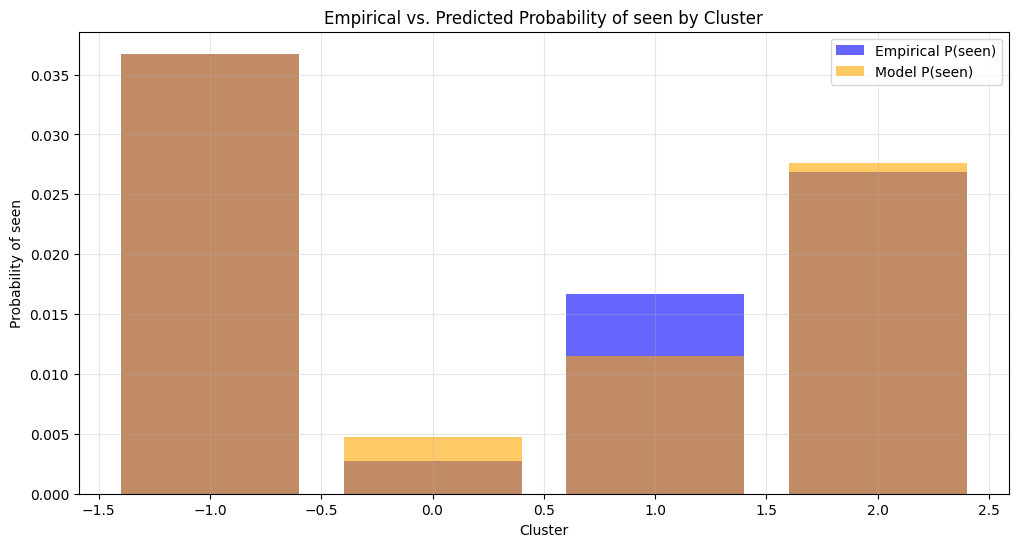

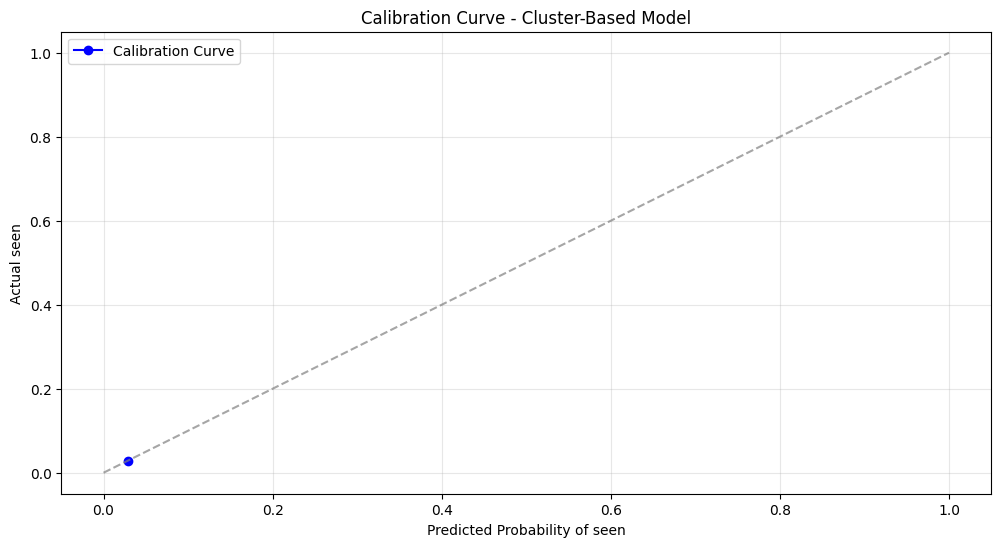

"Empirical 'seen' Probability and Count by Cluster:"

,Cluster,Probability,Count
0,-1,0.036746,58075
1,0,0.002714,13635
2,1,0.016657,8585
3,2,0.026884,29795


'Full Data with Seen Percentages:'

,indicator,Cluster,seen,seen_percentage
0,102.129.153.158,0,0,0.002714
1,102.129.153.158,0,0,0.002714
2,102.129.153.158,0,0,0.002714
3,102.129.153.158,0,0,0.002714
4,102.129.153.158,0,0,0.002714
5,102.129.153.158,0,0,0.002714
6,102.129.153.158,0,0,0.002714
7,102.129.153.158,0,0,0.002714
8,102.129.153.158,0,0,0.002714
9,102.129.153.158,0,0,0.002714


In [15]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
import hdbscan
from collections import Counter

# Load the new dataset
data = pd.read_csv(R'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\temporalData.csv')

# Select Relevant Features
features = ['seen_streak', 'days_since_last_seen_x', 'rolling_seen_ratio_7d', 
            'rolling_obs_7d', 'high_activity_not_seen_ratio_14d', 'rolling_seen_ratio_14d', 
            'volatility_ratio', 'seen_streak_prev', 'obs_ratio_spike', 'seen_ratio_diff']

# Aggregate Data by IP Address
X = data.groupby('indicator')[features].agg(['mean', 'std', 'max', 'min']).fillna(0)
X.columns = ['_'.join(col).strip() for col in X.columns.values]

# Feature Engineering
X['streak_volatility'] = X['seen_streak_mean'] * X['volatility_ratio_mean']
X['obs_spike_diff'] = X['obs_ratio_spike_mean'] - X['seen_ratio_diff_mean']
X['rolling_ratio_diff'] = X['rolling_seen_ratio_7d_mean'] / (X['rolling_obs_7d_mean'] + 1e-6)

# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply HDBSCAN
min_cluster_size = 15
min_samples = 15
metric = 'euclidean'

clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric=metric)
labels = clusterer.fit_predict(X_scaled)

# Mapping Cluster Labels to Original Data
label_map = dict(zip(X.index, labels))
data['Cluster'] = data['indicator'].map(label_map)

data['is_outlier'] = (data['Cluster'] == -1).astype(int)

# Calculate Empirical 'seen' Probabilities by Cluster
seen_probs = data.groupby('Cluster')['seen'].mean()
print("Empirical 'seen' Probability by Cluster:\n", seen_probs)

# Logistic Regression Model
log_model = LogisticRegression()
data['Cluster_Label'] = data['Cluster'].fillna(-1)
log_model.fit(data[['Cluster_Label', 'is_outlier']], data['seen'])
pred_probs = log_model.predict_proba(data[['Cluster_Label', 'is_outlier']])[:, 1]

# Model Evaluation Metrics
auc = roc_auc_score(data['seen'], pred_probs)
log_loss_score = log_loss(data['seen'], pred_probs)
brier_score = brier_score_loss(data['seen'], pred_probs)
print(f"AUC: {auc:.4f}")
print(f"Log Loss: {log_loss_score:.4f}")
print(f"Brier Score: {brier_score:.4f}")

# Visualization: Empirical vs. Predicted Probabilities
plt.figure(figsize=(12, 6))
plt.bar(seen_probs.index, seen_probs.values, color='blue', alpha=0.6, label='Empirical P(seen)')
plt.bar(seen_probs.index, [log_model.predict_proba(pd.DataFrame({'Cluster_Label': [label], 'is_outlier': [int(label == -1)]}))[0][1] for label in seen_probs.index], 
        color='orange', alpha=0.6, label='Model P(seen)')
plt.xlabel('Cluster')
plt.ylabel('Probability of seen')
plt.title('Empirical vs. Predicted Probability of seen by Cluster')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Calibration Curve
prob_true, prob_pred = calibration_curve(data['seen'], pred_probs, n_bins=10)
plt.figure(figsize=(12, 6))
plt.plot(prob_pred, prob_true, marker='o', linestyle='-', color='blue', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
plt.title("Calibration Curve - Cluster-Based Model")
plt.xlabel("Predicted Probability of seen")
plt.ylabel("Actual seen")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Calculate Empirical 'seen' Probabilities by Cluster
seen_probs = data.groupby('Cluster')['seen'].mean()
seen_counts = data.groupby('Cluster')['seen'].count()
seen_summary = pd.DataFrame({'Probability': seen_probs, 'Count': seen_counts}).reset_index()
display("Empirical 'seen' Probability and Count by Cluster:", seen_summary)

# Display Full Data with Cluster Labels and Seen Percentages
data['seen_percentage'] = data.groupby('Cluster')['seen'].transform('mean')
display("Full Data with Seen Percentages:", data[['indicator', 'Cluster', 'seen', 'seen_percentage']].head(20))

# Prediction Function for New Data
def predict_seen_probability(new_data):
    # Aggregate and Engineer Features
    new_X = new_data[features].agg(['mean', 'std', 'max', 'min']).fillna(0)
    new_X.columns = ['_'.join(col).strip() for col in new_X.columns.values]
    new_X['streak_volatility'] = new_X['seen_streak_mean'] * new_X['volatility_ratio_mean']
    new_X['obs_spike_diff'] = new_X['obs_ratio_spike_mean'] - new_X['seen_ratio_diff_mean']
    new_X['rolling_ratio_diff'] = new_X['rolling_seen_ratio_7d_mean'] / (new_X['rolling_obs_7d_mean'] + 1e-6)

    # Standardize the Data
    new_X_scaled = scaler.transform(new_X)

    # Determine Cluster Label
    new_label = clusterer.predict(new_X_scaled)[0]
    is_outlier = 1 if new_label == -1 else 0

    # Predict Probability
    pred_prob = log_model.predict_proba([[new_label, is_outlier]])[0][1]

    return pred_prob
